Exercise I

DATA download

/tmp/ipython-input-2656138064.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nikkei = yf.download('^N225', start='2015-10-18', end='2025-10-18')
[*********************100%***********************]  1 of 1 completed


Total returns: 2443


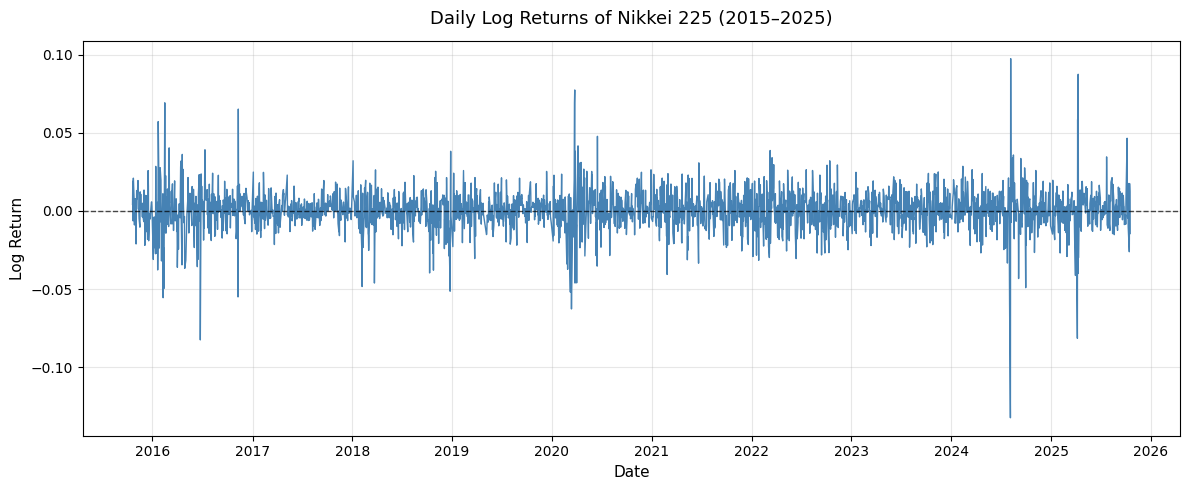

In [13]:
import yfinance as yf
import numpy as np
from scipy.stats import genextreme
import pandas as pd
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(55)

# Download data
nikkei = yf.download('^N225', start='2015-10-18', end='2025-10-18')
close = nikkei['Close']
ret = np.log(close / close.shift(1)).dropna()

print(f"Total returns: {len(ret)}")

# Plot time series of log returns
plt.figure(figsize=(12, 5))
plt.plot(ret.index, ret.values, color='steelblue', linewidth=1)
plt.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
plt.title('Daily Log Returns of Nikkei 225 (2015–2025)', fontsize=13, pad=12)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Log Return', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

define a function to do all (so can replicate for 10 and 40 blocks)

ANALYZING DIFFERENT BLOCK SIZES

Block size 10: 244 blocks

Block size 20: 122 blocks

Block size 40: 61 blocks

Block size 250: 9 blocks

COMPARISON TABLE: GEV PARAMETER ESTIMATES

1. SHAPE PARAMETER (ξ)
----------------------------------------------------------------------------------------------------
Block Size      Estimate        Std. Error      # Blocks       
----------------------------------------------------------------------------------------------------
10              0.772247        0.248742        244            
20              0.772400        0.272639        122            
40              0.322977        0.204085        61             
250             0.240561        1.230679        9              

2. LOCATION PARAMETER (μ)
----------------------------------------------------------------------------------------------------
Block Size      Estimate        Std. Error     
-------------------------------------------------------------------------------------------------

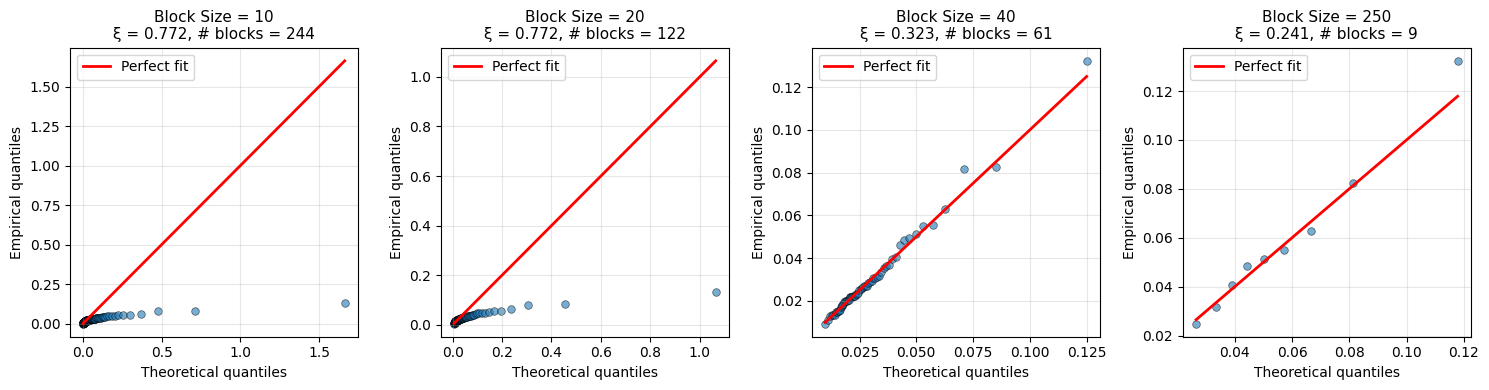

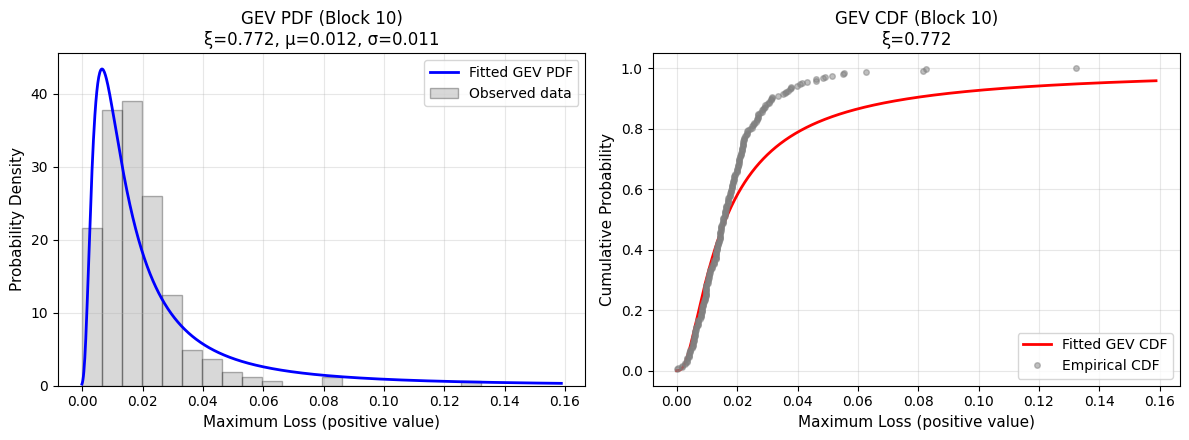

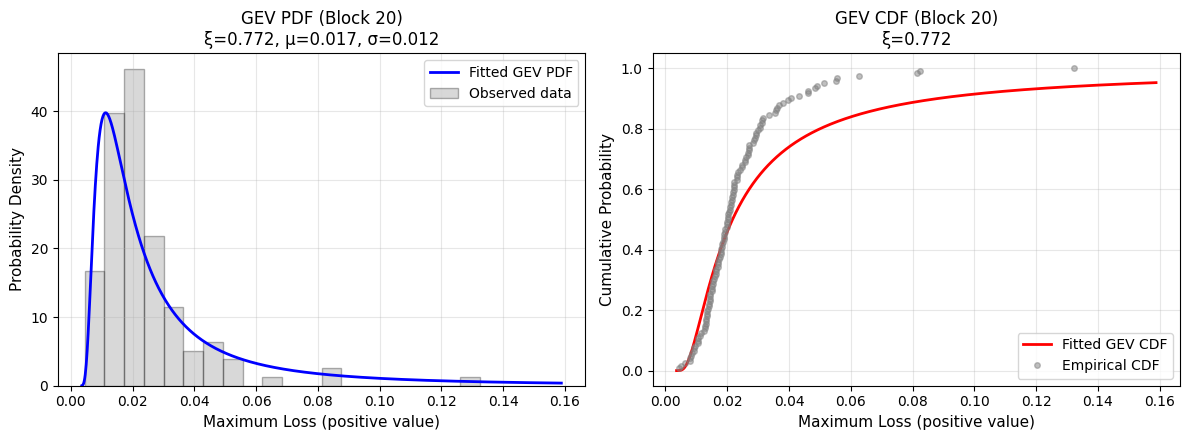

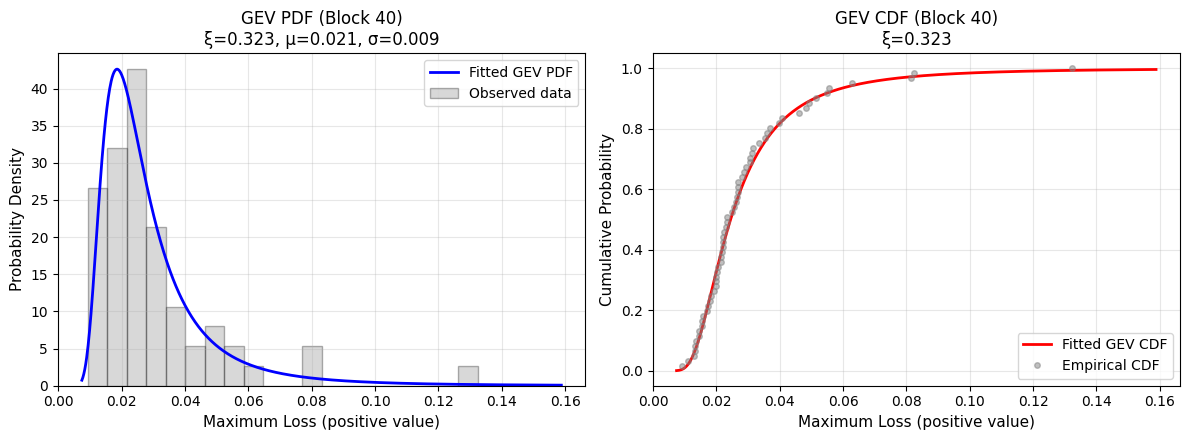

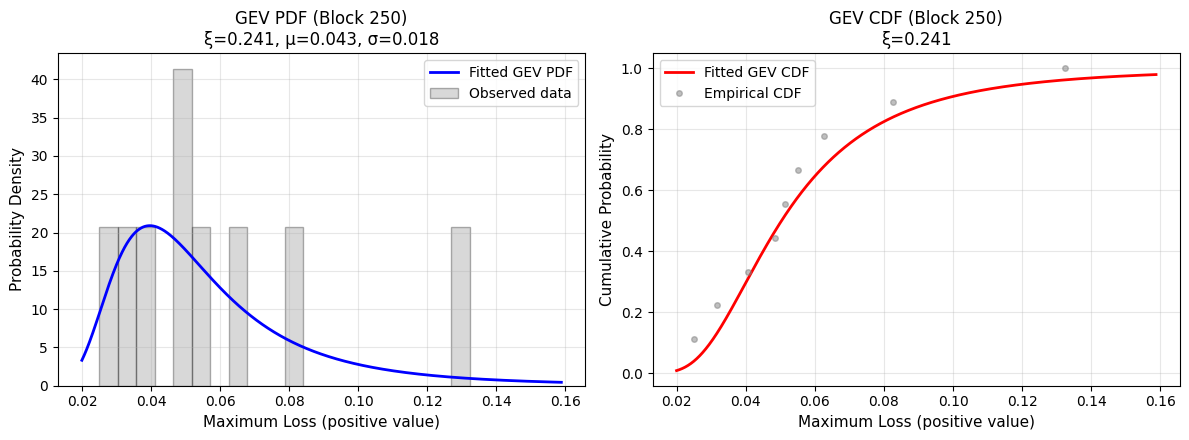

In [15]:
# Function to perform analysis for a given block size
def analyze_block_size(returns, blocksize):
    """
    Perform GEV analysis for a given block size
    Returns: fitted parameters, standard errors, return level, and CI
    """
    max_losses = []

    # Extract block maxima
    for i in range(0, len(returns), blocksize):
        block = returns.iloc[i:i+blocksize]
        if len(block) == blocksize:
            max_loss = -block.min()  # Convert minimum return to maximum loss (positive)
            max_losses.append(max_loss)

    max_losses_array = np.array(max_losses).flatten()

    print(f"\nBlock size {blocksize}: {len(max_losses_array)} blocks")

    # Fit GEV
    c_hat, loc_hat, scale_hat = genextreme.fit(max_losses_array)
    xi_hat = -c_hat  # Convert to standard EVT notation

    # Bootstrap for standard errors
    n_bootstrap = 1000
    bootstrap_estimates = []

    for i in range(n_bootstrap):
        bootstrap_sample = np.random.choice(max_losses_array, size=len(max_losses_array), replace=True)
        try:
            c_boot, loc_boot, scale_boot = genextreme.fit(bootstrap_sample)
            bootstrap_estimates.append([c_boot, loc_boot, scale_boot])
        except:
            continue

    bootstrap_estimates = np.array(bootstrap_estimates)

    # Calculate standard errors
    se_xi = np.std(bootstrap_estimates[:, 0])
    se_mu = np.std(bootstrap_estimates[:, 1])
    se_sigma = np.std(bootstrap_estimates[:, 2])

    ## Calculate 10-year return level
    blocks_per_year = 252 / blocksize
    return_period_blocks = 10 * blocks_per_year
    p_exceed = 1 / return_period_blocks
    p_quantile = 1 - p_exceed

    return_level = genextreme.ppf(p_quantile, c_hat, loc=loc_hat, scale=scale_hat)

    # Bootstrap confidence interval for return level
    bootstrap_return_levels = []

    for i in range(n_bootstrap):
        bootstrap_sample = np.random.choice(max_losses_array, size=len(max_losses_array), replace=True)
        try:
            c_boot, loc_boot, scale_boot = genextreme.fit(bootstrap_sample)
            rl_boot = genextreme.ppf(p_quantile, c_boot, loc=loc_boot, scale=scale_boot)
            bootstrap_return_levels.append(rl_boot)
        except:
            continue

    bootstrap_return_levels = np.array(bootstrap_return_levels)
    ci_lower = np.percentile(bootstrap_return_levels, 2.5)
    ci_upper = np.percentile(bootstrap_return_levels, 97.5)

    return {
        'blocksize': blocksize,
        'n_blocks': len(max_losses_array),
        'xi_hat': xi_hat,
        'se_xi': se_xi,
        'mu_hat': loc_hat,
        'se_mu': se_mu,
        'sigma_hat': scale_hat,
        'se_sigma': se_sigma,
        'return_level': return_level,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'max_losses_array': max_losses_array  # Return data for plotting
    }

# Analyze different block sizes
print("="*70)
print("ANALYZING DIFFERENT BLOCK SIZES")
print("="*70)

block_sizes = [10, 20, 40,250]
results = []

for bs in block_sizes:
    result = analyze_block_size(ret, bs)
    results.append(result)

# Create comparison table
print("\n" + "="*100)
print("COMPARISON TABLE: GEV PARAMETER ESTIMATES")
print("="*100)

# Create DataFrame for better formatting
df = pd.DataFrame(results)

# Print parameter estimates
print("\n1. SHAPE PARAMETER (ξ)")
print("-"*100)
print(f"{'Block Size':<15} {'Estimate':<15} {'Std. Error':<15} {'# Blocks':<15}")
print("-"*100)
for _, row in df.iterrows():
    print(f"{row['blocksize']:<15} {row['xi_hat']:<15.6f} {row['se_xi']:<15.6f} {row['n_blocks']:<15}")

print("\n2. LOCATION PARAMETER (μ)")
print("-"*100)
print(f"{'Block Size':<15} {'Estimate':<15} {'Std. Error':<15}")
print("-"*100)
for _, row in df.iterrows():
    print(f"{row['blocksize']:<15} {row['mu_hat']:<15.6f} {row['se_mu']:<15.6f}")

print("\n3. SCALE PARAMETER (σ)")
print("-"*100)
print(f"{'Block Size':<15} {'Estimate':<15} {'Std. Error':<15}")
print("-"*100)
for _, row in df.iterrows():
    print(f"{row['blocksize']:<15} {row['sigma_hat']:<15.6f} {row['se_sigma']:<15.6f}")

print("\n4. 10-YEAR RETURN LEVEL")
print("-"*100)
print(f"{'Block Size':<15} {'Return Level':<15} {'95% CI Lower':<15} {'95% CI Upper':<15}")
print("-"*100)
for _, row in df.iterrows():
    print(f"{row['blocksize']:<15} {row['return_level']:<15.6f} {row['ci_lower']:<15.6f} {row['ci_upper']:<15.6f}")

print("="*100)

# Create a nice summary table using pandas
print("\n" + "="*100)
print("SUMMARY TABLE (All Parameters)")
print("="*100)

summary_df = pd.DataFrame({
    'Block Size': df['blocksize'],
    'ξ (Shape)': df['xi_hat'].apply(lambda x: f"{x:.4f}"),
    'SE(ξ)': df['se_xi'].apply(lambda x: f"{x:.4f}"),
    'μ (Location)': df['mu_hat'].apply(lambda x: f"{x:.4f}"),
    'SE(μ)': df['se_mu'].apply(lambda x: f"{x:.4f}"),
    'σ (Scale)': df['sigma_hat'].apply(lambda x: f"{x:.4f}"),
    'SE(σ)': df['se_sigma'].apply(lambda x: f"{x:.4f}"),
    '10-Yr RL': df['return_level'].apply(lambda x: f"{x:.4f}"),
    'RL CI': df.apply(lambda row: f"[{row['ci_lower']:.4f}, {row['ci_upper']:.4f}]", axis=1)
})

print(summary_df.to_string(index=False))
print("="*100)

# ========================================
# FIGURE 1: Q-Q PLOTS (all 3 block sizes)
# ========================================
fig1, axes = plt.subplots(1, 4, figsize=(15, 4))

for idx, result in enumerate(results):
    bs = result['blocksize']
    max_losses_array = result['max_losses_array']

    # Refit to get parameters
    c_hat, loc_hat, scale_hat = genextreme.fit(max_losses_array)
    xi_hat = -c_hat

    # Create Q-Q plot
    emp_q = np.sort(max_losses_array)
    u = (np.arange(1, len(max_losses_array)+1) - 0.5) / len(max_losses_array)
    theo_q = genextreme.ppf(u, c_hat, loc=loc_hat, scale=scale_hat)

    axes[idx].scatter(theo_q, emp_q, s=30, alpha=0.6, edgecolors='black', linewidths=0.5)
    axes[idx].plot(theo_q, theo_q, 'r-', lw=2, label='Perfect fit')
    axes[idx].set_title(f"Block Size = {bs}\nξ = {xi_hat:.3f}, # blocks = {len(max_losses_array)}", fontsize=11)
    axes[idx].set_xlabel("Theoretical quantiles", fontsize=10)
    axes[idx].set_ylabel("Empirical quantiles", fontsize=10)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('qq_plots_all_blocks.png', dpi=150, bbox_inches='tight')
plt.show()

# ========================================
# FIGURE 2-4: PDF and CDF for each block size
# ========================================
for idx, result in enumerate(results):
    bs = result['blocksize']
    max_losses_array = result['max_losses_array']

    # Refit to get parameters
    c_hat, loc_hat, scale_hat = genextreme.fit(max_losses_array)
    xi_hat = -c_hat

    fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

    # Range of x-values
    x_min = max_losses_array.min() * 0.8
    x_max = max_losses_array.max() * 1.2
    x_range = np.linspace(x_min, x_max, 1000)

    # --- PDF plot ---
    pdf_values = genextreme.pdf(x_range, c_hat, loc=loc_hat, scale=scale_hat)
    ax1.plot(x_range, pdf_values, 'b-', linewidth=2, label='Fitted GEV PDF')
    ax1.hist(max_losses_array, bins=20, density=True, alpha=0.3,
             color='gray', edgecolor='black', label='Observed data')
    ax1.set_xlabel('Maximum Loss (positive value)', fontsize=11)
    ax1.set_ylabel('Probability Density', fontsize=11)
    ax1.set_title(f'GEV PDF (Block {bs})\nξ={xi_hat:.3f}, μ={loc_hat:.3f}, σ={scale_hat:.3f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- CDF plot ---
    cdf_values = genextreme.cdf(x_range, c_hat, loc=loc_hat, scale=scale_hat)
    ax2.plot(x_range, cdf_values, 'r-', linewidth=2, label='Fitted GEV CDF')

    sorted_data = np.sort(max_losses_array)
    empirical_cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax2.plot(sorted_data, empirical_cdf, 'o', markersize=4, alpha=0.5,
             color='gray', label='Empirical CDF')

    ax2.set_xlabel('Maximum Loss (positive value)', fontsize=11)
    ax2.set_ylabel('Cumulative Probability', fontsize=11)
    ax2.set_title(f'GEV CDF (Block {bs})\nξ={xi_hat:.3f}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'pdf_cdf_block_{bs}.png', dpi=150, bbox_inches='tight')
    plt.show()

GET PDF and CDF

NOTE: the choice of the block is critical, if we have the block size too small, we might obtain the maximum which is not representative. On the other hand, if we have the block size too huge, we may not have enough block maxima sample to form a distribution that can reflect/ represent the tail risk.

Small blocks (10, 20): More data points but many "non-extreme" observations → poor fit
Block Size 10 & 20: The points cluster near zero with a few extreme outliers. This means:
1. Most blocks have very small maximum losses (near zero)
2. Only a few blocks have significant losses

===================================================TASK4===================================================

In [1]:
import numpy as np
from scipy import stats
import pandas as pd

# Set random seed for reproducibility
np.random.seed(5510)

# Define the distributions
# L1: Student-t with nu=4, scaled to have std=0.02
nu1 = 4
# For student-t: std = sqrt(nu/(nu-2)) * scale
# We want std = 0.02, so scale = 0.02 / sqrt(nu/(nu-2))
scale1 = 0.02 / np.sqrt(nu1 / (nu1 - 2))
L1_dist = stats.t(df=nu1, loc=0, scale=scale1)

# L2: Normal with mean=0, std=0.015
L2_dist = stats.norm(loc=0, scale=0.015)

# L3: GPD with xi=0.2, beta=0.01
xi3 = 0.2
beta3 = 0.01
L3_dist = stats.genpareto(c=xi3, loc=0, scale=beta3)

# Calculate VaR and ES for each distribution
confidence_levels = [0.95, 0.99]

def calculate_var(dist, alpha):
    """Calculate Value at Risk at confidence level alpha"""
    return dist.ppf(alpha)

def calculate_es_numerical(dist, alpha, n_samples=1000000):
    """Calculate Expected Shortfall numerically"""
    samples = dist.rvs(size=n_samples)
    var = np.quantile(samples, alpha)
    # ES is the mean of losses exceeding VaR
    es = np.mean(samples[samples >= var])
    return es

# Calculate for each distribution
print("="*70)
print("PART 1: Individual Loss Distribution Risk Measures")
print("="*70)

distributions = {
    'L1 (Student-t, ν=4)': L1_dist,
    'L2 (Normal)': L2_dist,
    'L3 (GPD)': L3_dist
}

results_individual = []

for name, dist in distributions.items():
    print(f"\n{name}:")
    print("-" * 50)

    for alpha in confidence_levels:
        var = calculate_var(dist, alpha)
        es = calculate_es_numerical(dist, alpha)

        print(f"  VaR_{alpha}: {var:.6f}")
        print(f"  ES_{alpha}:  {es:.6f}")

        results_individual.append({
            'Distribution': name,
            'Confidence': alpha,
            'VaR': var,
            'ES': es
        })

df_individual = pd.DataFrame(results_individual)


PART 1: Individual Loss Distribution Risk Measures

L1 (Student-t, ν=4):
--------------------------------------------------
  VaR_0.95: 0.030149
  ES_0.95:  0.045336
  VaR_0.99: 0.052990
  ES_0.99:  0.073805

L2 (Normal):
--------------------------------------------------
  VaR_0.95: 0.024673
  ES_0.95:  0.030930
  VaR_0.99: 0.034895
  ES_0.99:  0.040013

L3 (GPD):
--------------------------------------------------
  VaR_0.95: 0.041028
  ES_0.95:  0.064069
  VaR_0.99: 0.075594
  ES_0.99:  0.106869


In [2]:
from scipy.stats import norm as normal
# from scipy.special import gamma

# Number of simulation scenarios
n_scenarios = 100000

print("\n" + "="*70)
print("PART 2: Aggregate Loss Simulation")
print("="*70)

# Function to simulate from Student-t copula manually
def simulate_student_t_copula(rho, nu, n):
    """
    Simulate from Student-t copula with correlation rho and degrees of freedom nu
    """
    # Create correlation matrix
    P = np.array([[1, rho, rho],
                  [rho, 1, rho],
                  [rho, rho, 1]])

    # Generate multivariate t distribution
    # Step 1: Generate chi-squared variable
    chi2 = np.random.chisquare(nu, n)

    # Step 2: Generate independent standard normals
    Z = np.random.multivariate_normal(np.zeros(3), P, n)

    # Step 3: Create multivariate t
    X = Z / np.sqrt(chi2 / nu)[:, np.newaxis]

    # Step 4: Convert to uniform using t CDF
    U = np.zeros_like(X)
    for i in range(3):
        U[:, i] = stats.t.cdf(X[:, i], df=nu)

    return U

# Scenario 1: Independence
print("\n" + "-"*70)
print("Scenario 1: INDEPENDENCE")
print("-"*70)

U1_indep = np.random.uniform(0, 1, n_scenarios)
U2_indep = np.random.uniform(0, 1, n_scenarios)
U3_indep = np.random.uniform(0, 1, n_scenarios)

# Transform to actual losses
L1_indep = L1_dist.ppf(U1_indep)
L2_indep = L2_dist.ppf(U2_indep)
L3_indep = L3_dist.ppf(U3_indep)

# Calculate aggregate loss
S_indep = (L1_indep + L2_indep + L3_indep) / 3

# Calculate risk measures
var_95_indep = np.quantile(S_indep, 0.95)
var_99_indep = np.quantile(S_indep, 0.99)
es_95_indep = np.mean(S_indep[S_indep >= var_95_indep])
es_99_indep = np.mean(S_indep[S_indep >= var_99_indep])

print(f"VaR_0.95(S) = {var_95_indep:.6f}")
print(f"VaR_0.99(S) = {var_99_indep:.6f}")
print(f"ES_0.95(S)  = {es_95_indep:.6f}")
print(f"ES_0.99(S)  = {es_99_indep:.6f}")

# Scenario 2: Gaussian Copula with ρ = 0.5
print("\n" + "-"*70)
print("Scenario 2: GAUSSIAN COPULA (ρ = 0.5)")
print("-"*70)

rho = 0.5
# Create correlation matrix
P_gauss = np.array([[1, rho, rho],
                    [rho, 1, rho],
                    [rho, rho, 1]])

# Generate from multivariate normal
Z_gauss = np.random.multivariate_normal(np.zeros(3), P_gauss, n_scenarios)

# Transform to uniform using normal CDF
U_gauss = normal.cdf(Z_gauss)

# Transform to actual losses
L1_gauss = L1_dist.ppf(U_gauss[:, 0])
L2_gauss = L2_dist.ppf(U_gauss[:, 1])
L3_gauss = L3_dist.ppf(U_gauss[:, 2])

# Calculate aggregate loss
S_gauss = (L1_gauss + L2_gauss + L3_gauss) / 3

# Calculate risk measures
var_95_gauss = np.quantile(S_gauss, 0.95)
var_99_gauss = np.quantile(S_gauss, 0.99)
es_95_gauss = np.mean(S_gauss[S_gauss >= var_95_gauss])
es_99_gauss = np.mean(S_gauss[S_gauss >= var_99_gauss])

print(f"VaR_0.95(S) = {var_95_gauss:.6f}")
print(f"VaR_0.99(S) = {var_99_gauss:.6f}")
print(f"ES_0.95(S)  = {es_95_gauss:.6f}")
print(f"ES_0.99(S)  = {es_99_gauss:.6f}")

# Scenario 3: Student-t Copula with ρ = 0.5, ν = 4
print("\n" + "-"*70)
print("Scenario 3: STUDENT-T COPULA (ρ = 0.5, ν = 4)")
print("-"*70)

nu_copula = 4
U_t = simulate_student_t_copula(rho, nu_copula, n_scenarios)

# Transform to actual losses
L1_t = L1_dist.ppf(U_t[:, 0])
L2_t = L2_dist.ppf(U_t[:, 1])
L3_t = L3_dist.ppf(U_t[:, 2])

# Calculate aggregate loss
S_t = (L1_t + L2_t + L3_t) / 3

# Calculate risk measures
var_95_t = np.quantile(S_t, 0.95)
var_99_t = np.quantile(S_t, 0.99)
es_95_t = np.mean(S_t[S_t >= var_95_t])
es_99_t = np.mean(S_t[S_t >= var_99_t])

print(f"VaR_0.95(S) = {var_95_t:.6f}")
print(f"VaR_0.99(S) = {var_99_t:.6f}")
print(f"ES_0.95(S)  = {es_95_t:.6f}")
print(f"ES_0.99(S)  = {es_99_t:.6f}")


PART 2: Aggregate Loss Simulation

----------------------------------------------------------------------
Scenario 1: INDEPENDENCE
----------------------------------------------------------------------
VaR_0.95(S) = 0.020249
VaR_0.99(S) = 0.032324
ES_0.95(S)  = 0.028125
ES_0.99(S)  = 0.042962

----------------------------------------------------------------------
Scenario 2: GAUSSIAN COPULA (ρ = 0.5)
----------------------------------------------------------------------
VaR_0.95(S) = 0.026733
VaR_0.99(S) = 0.044176
ES_0.95(S)  = 0.038099
ES_0.99(S)  = 0.058467

----------------------------------------------------------------------
Scenario 3: STUDENT-T COPULA (ρ = 0.5, ν = 4)
----------------------------------------------------------------------
VaR_0.95(S) = 0.026285
VaR_0.99(S) = 0.044468
ES_0.95(S)  = 0.038332
ES_0.99(S)  = 0.060743


Part 3: Verify numerically that ES0.99 satisfies the subadditivity property for your simulated portfolios, while VaR0.99 may not.

In [3]:
# Subadditivity Verification
print("\n" + "="*70)
print("SUBADDITIVITY VERIFICATION (α = 0.99)")
print("="*70)

alpha = 0.99

# Individual risk measures
var_L1 = calculate_var(L1_dist, alpha)
var_L2 = calculate_var(L2_dist, alpha)
var_L3 = calculate_var(L3_dist, alpha)
sum_var = (var_L1 + var_L2 + var_L3) / 3

es_L1 = calculate_es_numerical(L1_dist, alpha)
es_L2 = calculate_es_numerical(L2_dist, alpha)
es_L3 = calculate_es_numerical(L3_dist, alpha)
sum_es = (es_L1 + es_L2 + es_L3) / 3

# Aggregate risk measures for each copula
scenarios = ['Independence', 'Gaussian', 'Student-t']
S_list = [S_indep, S_gauss, S_t]

results = []
for name, S in zip(scenarios, S_list):
    var_S = np.quantile(S, alpha)
    es_S = np.mean(S[S >= var_S])

    results.append({
        'Copula': name,
        'VaR(S)': var_S,
        'Sum_VaR/3': sum_var,
        'VaR_Subadditive': '✓' if var_S <= sum_var else '✗',
        'ES(S)': es_S,
        'Sum_ES/3': sum_es,
        'ES_Subadditive': '✓' if es_S <= sum_es else '✗'
    })

df = pd.DataFrame(results)
print("\n" + df.to_string(index=False))



SUBADDITIVITY VERIFICATION (α = 0.99)

      Copula   VaR(S)  Sum_VaR/3 VaR_Subadditive    ES(S)  Sum_ES/3 ES_Subadditive
Independence 0.032324   0.054493               ✓ 0.042962  0.073735              ✓
    Gaussian 0.044176   0.054493               ✓ 0.058467  0.073735              ✓
   Student-t 0.044468   0.054493               ✓ 0.060743  0.073735              ✓


For our case both VaR and ES satisfy subadditivity, however which is not the usual case because VaR is not a coherent risk measure. There are examples where diversification does not necessarily lower risk levels. Furthermore,
assuming subadditivity means VaR can not be used as a coherent risk measure.

In [4]:
# Subadditivity Verification
print("\n" + "="*70)
print("SUBADDITIVITY VERIFICATION (α = 0.95)")
print("="*70)

alpha = 0.95

# Individual risk measures
var_L1 = calculate_var(L1_dist, alpha)
var_L2 = calculate_var(L2_dist, alpha)
var_L3 = calculate_var(L3_dist, alpha)
sum_var = (var_L1 + var_L2 + var_L3) / 3

es_L1 = calculate_es_numerical(L1_dist, alpha)
es_L2 = calculate_es_numerical(L2_dist, alpha)
es_L3 = calculate_es_numerical(L3_dist, alpha)
sum_es = (es_L1 + es_L2 + es_L3) / 3

# Aggregate risk measures for each copula
scenarios = ['Independence', 'Gaussian', 'Student-t']
S_list = [S_indep, S_gauss, S_t]

results = []
for name, S in zip(scenarios, S_list):
    var_S = np.quantile(S, alpha)
    es_S = np.mean(S[S >= var_S])

    results.append({
        'Copula': name,
        'VaR(S)': var_S,
        'Sum_VaR/3': sum_var,
        'VaR_Subadditive': '✓' if var_S <= sum_var else '✗',
        'ES(S)': es_S,
        'Sum_ES/3': sum_es,
        'ES_Subadditive': '✓' if es_S <= sum_es else '✗'
    })

df = pd.DataFrame(results)
print("\n" + df.to_string(index=False))



SUBADDITIVITY VERIFICATION (α = 0.95)

      Copula   VaR(S)  Sum_VaR/3 VaR_Subadditive    ES(S)  Sum_ES/3 ES_Subadditive
Independence 0.020249    0.03195               ✓ 0.028125  0.046655              ✓
    Gaussian 0.026733    0.03195               ✓ 0.038099  0.046655              ✓
   Student-t 0.026285    0.03195               ✓ 0.038332  0.046655              ✓


Part 4

In [5]:
# Scenario 4: Comonotonic (Perfect Positive Dependence)
print("\n" + "-"*70)
print("Scenario 4: COMONOTONIC (Perfect Positive Dependence)")
print("-"*70)

# For comonotonic risks, use the SAME uniform for all three
U_comono = np.random.uniform(0, 1, n_scenarios)

# Transform to actual losses using the same U
L1_comono = L1_dist.ppf(U_comono)
L2_comono = L2_dist.ppf(U_comono)
L3_comono = L3_dist.ppf(U_comono)

# Calculate aggregate loss (total sum)
S_comono_total = L1_comono + L2_comono + L3_comono

# Also calculate for comparison with other scenarios (divided by 3)
S_comono = S_comono_total / 3

# Calculate risk measures for total sum
var_95_comono = np.quantile(S_comono_total, 0.95)
var_99_comono = np.quantile(S_comono_total, 0.99)
es_95_comono = np.mean(S_comono_total[S_comono_total >= var_95_comono])
es_99_comono = np.mean(S_comono_total[S_comono_total >= var_99_comono])

print(f"VaR_0.95(S_total) = {var_95_comono:.6f}") #all without /3
print(f"VaR_0.99(S_total) = {var_99_comono:.6f}")
print(f"ES_0.95(S_total)  = {es_95_comono:.6f}")
print(f"ES_0.99(S_total)  = {es_99_comono:.6f}")

# Calculate individual VaRs and verify additivity
print("\n" + "="*70)
print("VERIFICATION: VaR Additivity for Comonotonic Risks")
print("="*70)

for alpha in confidence_levels:
    # Individual VaRs
    var_L1 = calculate_var(L1_dist, alpha)
    var_L2 = calculate_var(L2_dist, alpha)
    var_L3 = calculate_var(L3_dist, alpha)
    sum_var_theoretical = var_L1 + var_L2 + var_L3

    # Simulated VaR of sum
    var_sum_simulated = np.quantile(S_comono_total, alpha)

    # Error
    error = abs(var_sum_simulated - sum_var_theoretical)

    print(f"\nα = {alpha}:")
    print(f"  individual_VaR(L₁)               = {var_L1:.6f}")
    print(f"  individual_VaR(L₂)               = {var_L2:.6f}")
    print(f"  individual_VaR(L₃)               = {var_L3:.6f}")
    print(f"  Sum: VaR(L₁)+VaR(L₂)+VaR(L₃)     = {sum_var_theoretical:.6f}")
    print(f"  Simulated: VaR(L₁+L₂+L₃)         = {var_sum_simulated:.6f}")
    print(f"  Absolute Error                   = {error:.6f}")
    print(f"  ✓ VaR is additive for comonotonic risks!")

# Create comprehensive comparison table
print("\n" + "="*70)
print("COMPARISON OF AGGREGATE RISK MEASURES (S = (L₁+L₂+L₃)/3)")
print("="*70)

comparison_data = {
    'Dependence Structure': ['Independence', 'Gaussian Copula', 'Student-t Copula', 'Comonotonic'],
    'VaR_0.95': [var_95_indep, var_95_gauss, var_95_t, np.quantile(S_comono, 0.95)],
    'VaR_0.99': [var_99_indep, var_99_gauss, var_99_t, np.quantile(S_comono, 0.99)],
    'ES_0.95': [es_95_indep, es_95_gauss, es_95_t, np.mean(S_comono[S_comono >= np.quantile(S_comono, 0.95)])],
    'ES_0.99': [es_99_indep, es_99_gauss, es_99_t, np.mean(S_comono[S_comono >= np.quantile(S_comono, 0.99)])]
}

df_comparison = pd.DataFrame(comparison_data)
print("\n" + df_comparison.to_string(index=False))



----------------------------------------------------------------------
Scenario 4: COMONOTONIC (Perfect Positive Dependence)
----------------------------------------------------------------------
VaR_0.95(S_total) = 0.096048
VaR_0.99(S_total) = 0.166693
ES_0.95(S_total)  = 0.142370
ES_0.99(S_total)  = 0.226588

VERIFICATION: VaR Additivity for Comonotonic Risks

α = 0.95:
  individual_VaR(L₁)               = 0.030149
  individual_VaR(L₂)               = 0.024673
  individual_VaR(L₃)               = 0.041028
  Sum: VaR(L₁)+VaR(L₂)+VaR(L₃)     = 0.095850
  Simulated: VaR(L₁+L₂+L₃)         = 0.096048
  Absolute Error                   = 0.000198
  ✓ VaR is additive for comonotonic risks!

α = 0.99:
  individual_VaR(L₁)               = 0.052990
  individual_VaR(L₂)               = 0.034895
  individual_VaR(L₃)               = 0.075594
  Sum: VaR(L₁)+VaR(L₂)+VaR(L₃)     = 0.163479
  Simulated: VaR(L₁+L₂+L₃)         = 0.166693
  Absolute Error                   = 0.003214
  ✓ VaR is additiv

From the slide: In our case, the $VaR_\alpha(S)$ that is derived from $\frac{L_1+L_2+L_3}{3}$ is indeed the upper bound of the risk measures because $L_1,L_2,L_3$ are comotonic. However, we dont know the lower bound, the only lower VaR bound that can be derived is when we have the countermonotonic copula with d=2.
